# Importo las librerias

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Llamo a los datos

In [2]:
Ruta_dia3 = 'Mediciones_dia3'
Archivos_dia3 = os.listdir(Ruta_dia3)
Mediciones = []
for archivo in Archivos_dia3:
    if archivo != 'Resultados_dia3.py':
        Mediciones.append(archivo)

## Datos lampara

In [3]:
# Emision de lampara
Emision_lampara = {}
Emision_lampara_datos = pd.read_pickle('Mediciones_dia3/Control/Emision.pickle')
Emision_lampara['Intensidad'] = np.array(Emision_lampara_datos['Intensidad'].iloc[0])
Emision_lampara['err_Intensidad'] = np.array(Emision_lampara_datos['err_Intensidad'].iloc[0])
Emision_lampara['Longitud_onda'] = np.array(Emision_lampara_datos['Longitud_onda'].iloc[0])
Emision_lampara['err_Longitud_onda'] = np.array(Emision_lampara_datos['err_Longitud_onda'].iloc[0])

# Emision de lampara
Absorcion_lampara = {}
Absorcion_lampara_datos = pd.read_pickle('Mediciones_dia3/Control/Absorcion.pickle')
Absorcion_lampara['Intensidad'] = np.array(Absorcion_lampara_datos['Intensidad'].iloc[0])
Absorcion_lampara['err_Intensidad'] = np.array(Absorcion_lampara_datos['err_Intensidad'].iloc[0])
Absorcion_lampara['Longitud_onda'] = np.array(Absorcion_lampara_datos['Longitud_onda'].iloc[0])
Absorcion_lampara['err_Longitud_onda'] = np.array(Absorcion_lampara_datos['err_Longitud_onda'].iloc[0])



## Datos emision

In [4]:
Emision_datos = {}

# Busco todas las concentraciones
for concentracion in Mediciones:
    Dir_concentracion = Ruta_dia3 + f'/{concentracion}' + '/Emision.pickle'
    
    print(Dir_concentracion)
    df_Emision = pd.read_pickle(Dir_concentracion)
    
    # Valores de intensidad
    try:
        Intensidad = np.array(df_Emision['Intensidad'].iloc[0])
        err_Intensidad = np.array(df_Emision['err_Intensidad'].iloc[0])


        # Valores de Longitud de onda
        Longitud = np.array(df_Emision['Longitud_onda'].iloc[0])
        err_Longitud = np.array(df_Emision['err_Longitud_onda'].iloc[0])
        
        #--> Agrego al diccionario los datos
        Emision_datos[f'Intensidad_{concentracion}'] = Intensidad
        Emision_datos[f'err_Intensidad_{concentracion}'] = err_Intensidad
        Emision_datos[f'Longitud_{concentracion}'] = Longitud
        Emision_datos[f'err_Longitud_{concentracion}'] = err_Longitud
    except Exception as e:
        print(f'Error {e}, con {Dir_concentracion}')
    
Emisiones = pd.DataFrame(Emision_datos)

Mediciones_dia3/Control/Emision.pickle
Mediciones_dia3/Fluoresceina_0.5mM/Emision.pickle
Mediciones_dia3/Fluoresceina_0.5mMdecantado/Emision.pickle
Mediciones_dia3/Fluoresceina_1mM/Emision.pickle
Mediciones_dia3/FluRo_11/Emision.pickle
Mediciones_dia3/Rodamina0.5e-5/Emision.pickle
Mediciones_dia3/Rodamina1.2e-5M/Emision.pickle
Error 'Intensidad', con Mediciones_dia3/Rodamina1.2e-5M/Emision.pickle
Mediciones_dia3/Ro_0.6e-5_flu/Emision.pickle
Mediciones_dia3/Ro_0.75e-4_flu/Emision.pickle
Mediciones_dia3/Ro_0.825e-5_flu/Emision.pickle
Mediciones_dia3/Ro_062e-4_flu/Emision.pickle
Mediciones_dia3/Ro_1.5e-6M_flu/Emision.pickle
Mediciones_dia3/Ro_1.75e-5_flu/Emision.pickle
Mediciones_dia3/Ro_1.825e-5_flu/Emision.pickle
Mediciones_dia3/Ro_3.5e-5_Flu/Emision.pickle
Mediciones_dia3/Ro_3.75e-6_flu/Emision.pickle
Mediciones_dia3/Ro_4.85e-5_Flu/Emision.pickle
Mediciones_dia3/Ro_4.875e-6_Flue/Emision.pickle
Error 'Intensidad', con Mediciones_dia3/Ro_4.875e-6_Flue/Emision.pickle
Mediciones_dia3/Vacia

## Datos abosorcion

In [5]:
Absorcion_datos = {}

# Busco todas las concentraciones
for concentracion in Mediciones:
    Dir_concentracion = Ruta_dia3 + f'/{concentracion}' + '/Absorcion.pickle'
    
    df_Absorcion = pd.read_pickle(Dir_concentracion)
    
    try:
        # Valores de intensidad
        Intensidad = np.array(df_Absorcion['Intensidad'].iloc[0])
        err_Intensidad = np.array(df_Absorcion['err_Intensidad'].iloc[0])


        # Valores de Longitud de onda
        Longitud = np.array(df_Absorcion['Longitud_onda'].iloc[0])
        err_Longitud = np.array(df_Absorcion['err_Longitud_onda'].iloc[0])
        
        #--> Agrego al diccionario los datos
        Absorcion_datos[f'Intensidad_{concentracion}'] = Intensidad
        Absorcion_datos[f'err_Intensidad_{concentracion}'] = err_Intensidad
        Absorcion_datos[f'Longitud_{concentracion}'] = Longitud
        Absorcion_datos[f'err_Longitud_{concentracion}'] = err_Longitud
    except Exception as e:
        print(f'Error {e}, con {Dir_concentracion}')
    
Absorciones = pd.DataFrame(Absorcion_datos)

# Figuras

In [6]:
a = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
a[a < 5]

array([0, 1, 2, 3, 4])

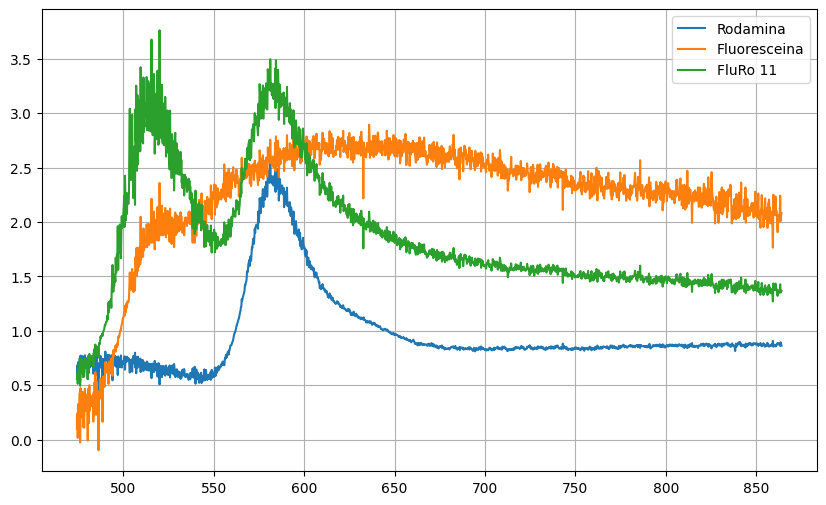

In [7]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina absorcion
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'Rodamina')

# Fluo emision
plt.plot(Emision_datos['Longitud_Fluoresceina_1mM'][a:b], Emision_datos['Intensidad_Fluoresceina_1mM'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'Fluoresceina')

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'FluRo 11')


plt.grid(), plt.legend(loc = 'upper right')
plt.show()

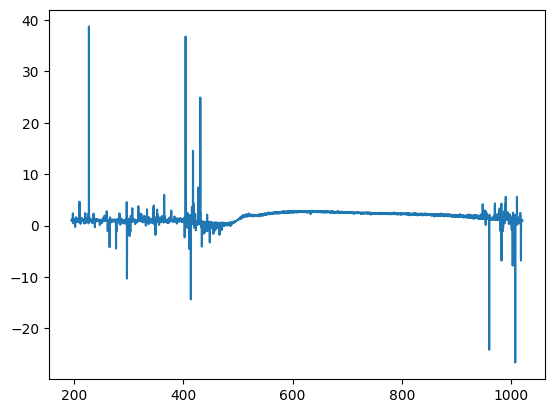

In [8]:
a, b = 0, -1
plt.plot(Emision_datos['Longitud_Fluoresceina_1mM'][a:b], Emision_datos['Intensidad_Fluoresceina_1mM'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'Fluoresceina')